In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving creditcard-data.xlsx to creditcard-data.xlsx


In [ ]:
data=pd.read_excel('creditcard-data.xlsx')
print(data.head())
print(data.info())
print(data.describe())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines_new  \
0         1.0               1.0                                  0.766127   
1         2.0               0.0                                  0.957151   
2         3.0               0.0                                  0.658180   
3         4.0               0.0                                  0.233810   
4         5.0               0.0                                  0.907239   

    age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio_New  MonthlyIncome  \
0  45.0                                   2.0       0.802982         9120.0   
1  40.0                                   0.0       0.121876         2600.0   
2  38.0                                   1.0       0.085113         3042.0   
3  30.0                                   0.0       0.036050         3300.0   
4  49.0                                   1.0       0.024926        63588.0   

   Monthlyincome_new  NumberOfOpenCreditLinesAndLoans  \
0    

In [ ]:
#Check the dataset for null values
data.isna().sum()
#Delete the null values which are empty rows in the dataset
data.dropna(how='all',inplace=True)
data.dropna(axis=0, inplace=True)
data.isna().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines_new,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio_New,0
MonthlyIncome,0
Monthlyincome_new,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0


In [ ]:
#Prepare to split the data into train and test datasets to train the model
from sklearn.model_selection import train_test_split

#Define the features(X) and the target(Y)
X= data[['RevolvingUtilizationOfUnsecuredLines_new','age','DebtRatio_New','Monthlyincome_new','NumberOfDependents']]
y=data['SeriousDlqin2yrs']

#spliting the data
X_train, X_val, y_train, y_val=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Success! Model Training Set size: {X_train.shape[0]} rows")

Success! Model Training Set size: 119995 rows


In [ ]:
#Performing standardization using the standard scaler
from sklearn.preprocessing import StandardScaler

#Initializing the scaler
scaler=StandardScaler()

#Fit on training data (learns the mean and std dev)
X_train_scaled=scaler.fit_transform(X_train)

#Transform both sets (applies the math)
X_val_scaled=scaler.transform(X_val)
print("Data scaled! Every variable now has a mean of 0 and a standard deviation of 1.")


Data scaled! Every variable now has a mean of 0 and a standard deviation of 1.


In [ ]:
#Training the logistic regression model
from sklearn.linear_model import LogisticRegression

#initialize the model
model=LogisticRegression(solver='liblinear',random_state=42)

#fitting the data into the model
model.fit(X_train_scaled,y_train)

print("model training completed")

model training completed


In [ ]:
# Create a table of the features and their calculated weights
importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
})

# Sort them to see the most influential factors
print(importance.sort_values(by='Weight', ascending=False))

                                    Feature    Weight
0  RevolvingUtilizationOfUnsecuredLines_new  0.930444
2                             DebtRatio_New  0.118654
4                        NumberOfDependents  0.098257
3                         Monthlyincome_new -0.151514
1                                       age -0.216139


In [ ]:
#Generate the predictions
y_pred=model.predict(X_val_scaled)

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print(f"Overall Accuracy: {accuracy_score(y_val, y_pred):.2%}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_val, y_pred))

Overall Accuracy: 93.32%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.97     27994
         1.0       0.00      0.00      0.00      2005

    accuracy                           0.93     29999
   macro avg       0.47      0.50      0.48     29999
weighted avg       0.87      0.93      0.90     29999



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#retrain the model with balanced weights
model_balanced=LogisticRegression(solver='liblinear',class_weight='balanced',random_state=42)
model_balanced.fit(X_train_scaled,y_train)

y_pred_balanced=model_balanced.predict(X_val_scaled)

print("--- Balanced Classification Report ---")
print(classification_report(y_val, y_pred_balanced))


--- Balanced Classification Report ---
              precision    recall  f1-score   support

         0.0       0.97      0.75      0.84     27994
         1.0       0.17      0.71      0.27      2005

    accuracy                           0.74     29999
   macro avg       0.57      0.73      0.56     29999
weighted avg       0.92      0.74      0.81     29999



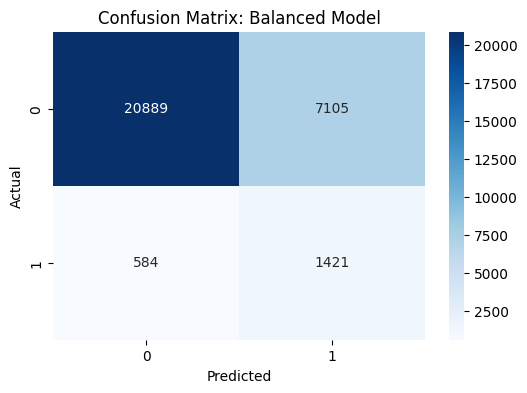

In [ ]:
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cm=confusion_matrix(y_val,y_pred_balanced)

# Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Balanced Model')
plt.show()

Final Model AUC Score: 0.7852


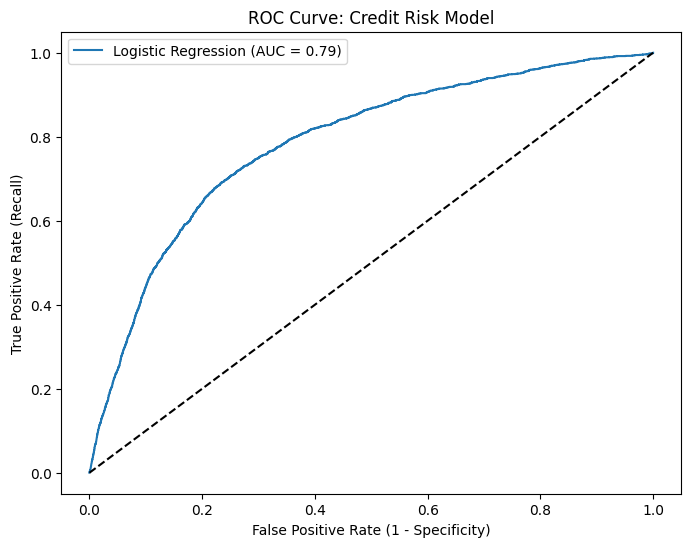

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Get the PROBABILITIES instead of just 0 or 1
# This gives the model's 'confidence' score (e.g., 0.85 chance of default)
y_pred_proba = model_balanced.predict_proba(X_val_scaled)[:, 1]

# 2. Calculate the AUC Score
auc_score = roc_auc_score(y_val, y_pred_proba)

print(f"Final Model AUC Score: {auc_score:.4f}")

# 3. Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # The 'Random Guess' line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Credit Risk Model')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# 1. Create the dataframe using the scaled validation features
# We convert the scaled array back into a DataFrame so we have column names
export_df = pd.DataFrame(X_val_scaled, columns=['RevolvingUtilizationOfUnsecuredLines_new', 'age', 'DebtRatio_New', 'Monthlyincome_new', 'NumberOfDependents'])

# 2. Add the Target and the Model's "Intelligence"
export_df['Actual_Default'] = y_val.values  # .values ensures the rows align perfectly
export_df['Predicted_Probability'] = y_pred_proba
export_df['Model_Prediction'] = y_pred_balanced

# 3. Export the file
export_df.to_csv('Risk_Model_Outputs.csv', index=False)

print("File 'Risk_Model_Outputs.csv' is ready for download!")

File 'Risk_Model_Outputs.csv' is ready for download!
